# Student Dropout Prediction Notebook

This notebook reproduces your script as a step-by-step workflow:
1. Load libraries and dataset
2. Clean and preprocess target labels
3. Visualize correlations and class-wise distributions
4. Train and evaluate a Random Forest classifier
5. Compare split seeds and cross-validation results
6. Plot normalized confusion matrix
7. Retrain using only 1% of training data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Question 1 
Load the dataset and display basic information

In [40]:
# Question 1
# Load the dataset and display basic information about it
df = pd.read_csv('data.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

## Question 2
1. Visualise the data to see if any features are redundant and the overall distribution of the features within the two classes
2. Interpret the results

In [41]:
# Clean column names in case they contain extra whitespace or quotes
df.columns = df.columns.str.strip().str.replace('"', '')

# Map Target to binary: 0=Dropout, 1=Enrolled/Graduate
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 1}
df['Target'] = df['Target'].map(target_mapping)

# Drop potential NaNs after mapping
df = df.dropna(subset=['Target'])

X = df.drop('Target', axis=1)
y = df['Target']

print(f'Dataset shape: {df.shape}')
print(y.value_counts().rename(index={0: 'Dropout (0)', 1: 'Success (1)'}))

Dataset shape: (4424, 37)
Target
Success (1)    3003
Dropout (0)    1421
Name: count, dtype: int64


## 1) Visualize Redundancy and Distribution

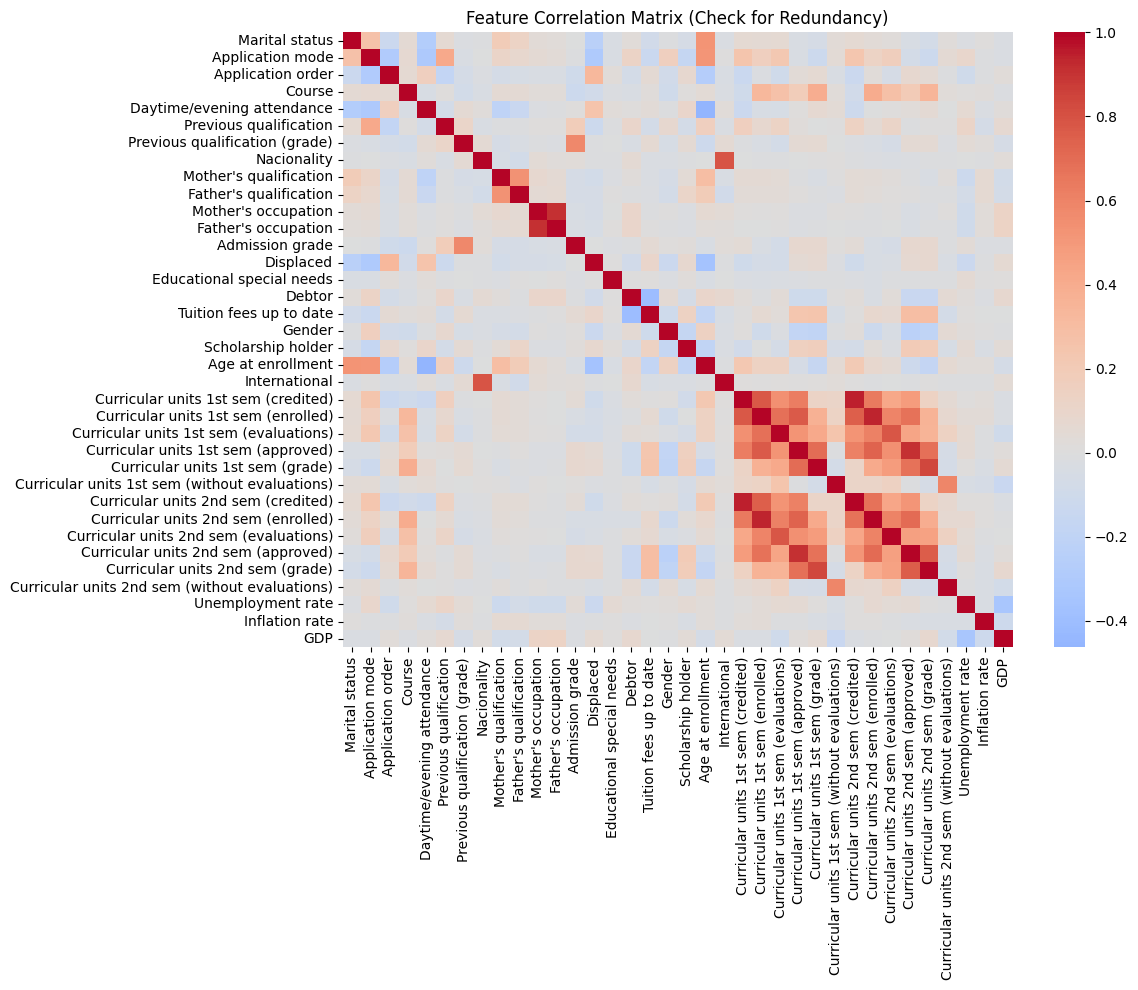

In [42]:
# Correlation matrix to detect redundant features
plt.figure(figsize=(12, 10))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix (Check for Redundancy)')
plt.tight_layout()
plt.show()

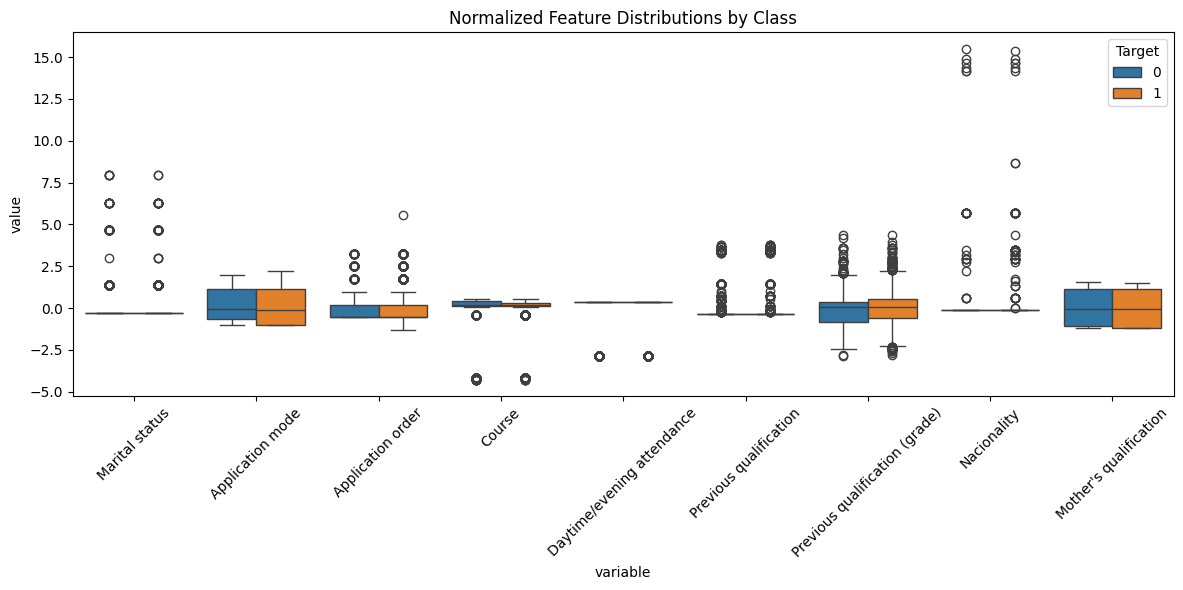

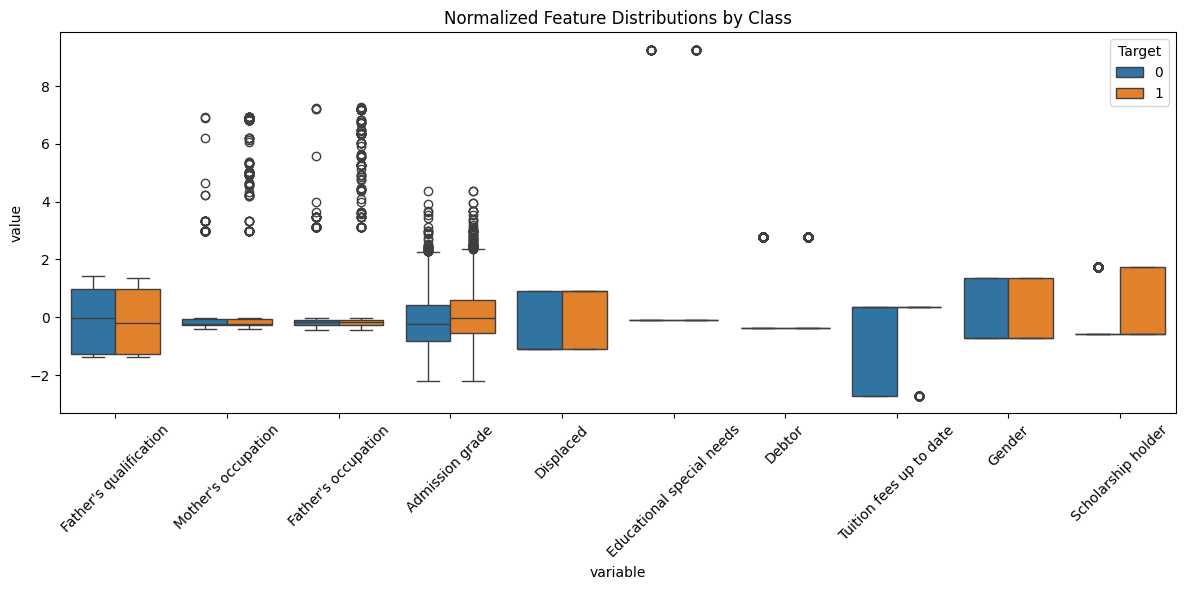

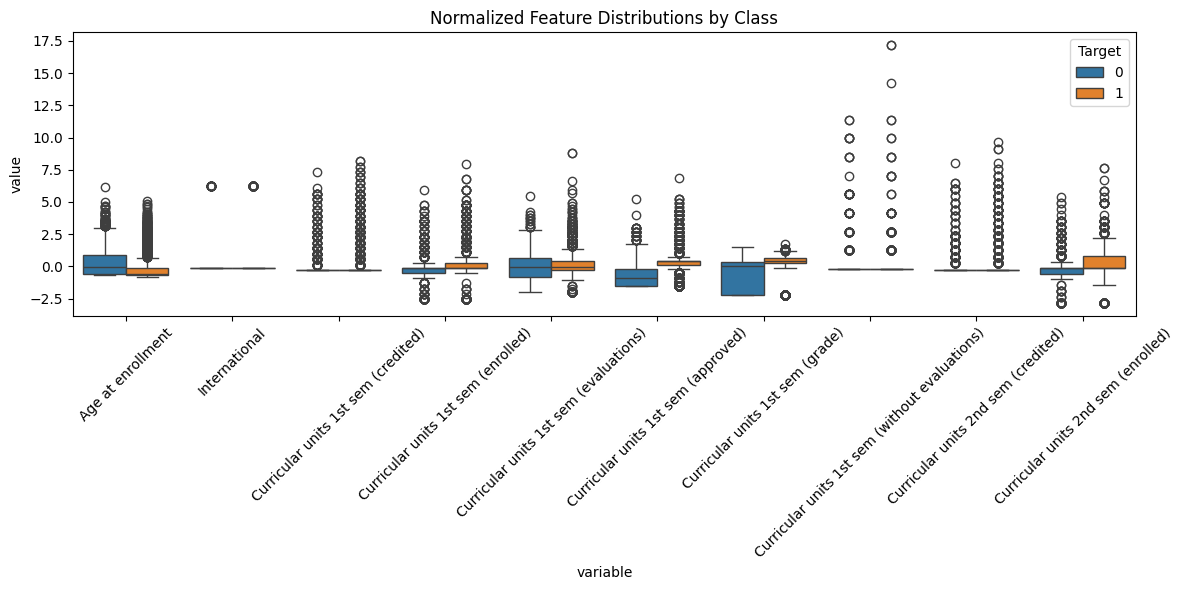

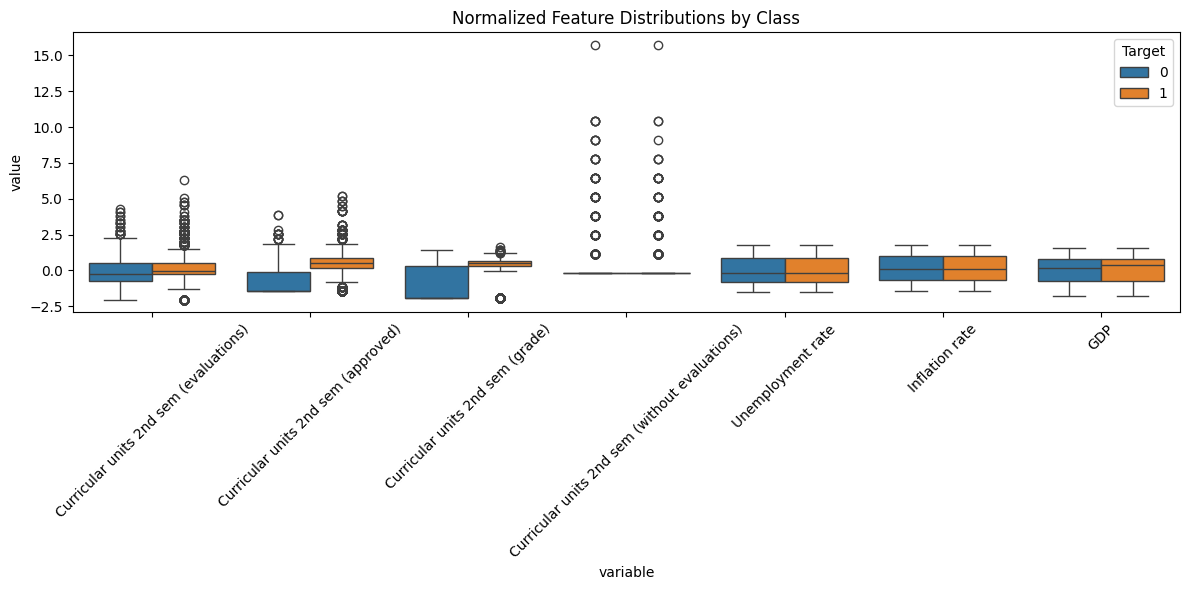

In [59]:
# Normalize features for distribution visualization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled['Target'] = y.reset_index(drop=True)

# Plot a subset of features to avoid visual clutter
features_to_plot = X.columns[:9]
X_melted = pd.melt(X_scaled, id_vars=['Target'], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Target', data=X_melted)
plt.title('Normalized Feature Distributions by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot a subset of features to avoid visual clutter
features_to_plot = X.columns[9:19]
X_melted = pd.melt(X_scaled, id_vars=['Target'], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Target', data=X_melted)
plt.title('Normalized Feature Distributions by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot a subset of features to avoid visual clutter
features_to_plot = X.columns[19:29]
X_melted = pd.melt(X_scaled, id_vars=['Target'], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Target', data=X_melted)
plt.title('Normalized Feature Distributions by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot a subset of features to avoid visual clutter
features_to_plot = X.columns[29:]
X_melted = pd.melt(X_scaled, id_vars=['Target'], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Target', data=X_melted)
plt.title('Normalized Feature Distributions by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X_scaled = X_scaled.drop('Target', axis=1)

## 2) Train/Test Split and Baseline Classifier

In [63]:
# Split dataset 90/10
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Train Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f'Training Accuracy: {train_acc:.4f}')
print(f'Testing Accuracy: {test_acc:.4f}')

# Optional full report
print('\nClassification Report (test split):')
print(classification_report(y_test, clf.predict(X_test), target_names=['Dropout (0)', 'Success (1)']))

Training Accuracy: 1.0000
Testing Accuracy: 0.8736

Classification Report (test split):
              precision    recall  f1-score   support

 Dropout (0)       0.84      0.76      0.80       147
 Success (1)       0.89      0.93      0.91       296

    accuracy                           0.87       443
   macro avg       0.86      0.85      0.85       443
weighted avg       0.87      0.87      0.87       443



In [64]:
# Change random seed and evaluate
X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
    X, y, test_size=0.10, random_state=99
)

clf_seed = RandomForestClassifier(random_state=42)
clf_seed.fit(X_train_seed, y_train_seed)

print(f'Testing Accuracy with seed 99: {accuracy_score(y_test_seed, clf_seed.predict(X_test_seed)):.4f}')

# 10-fold cross-validation
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=10)
print(f'10-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

Testing Accuracy with seed 99: 0.8826
10-Fold CV Accuracy: 0.8741 (+/- 0.0297)


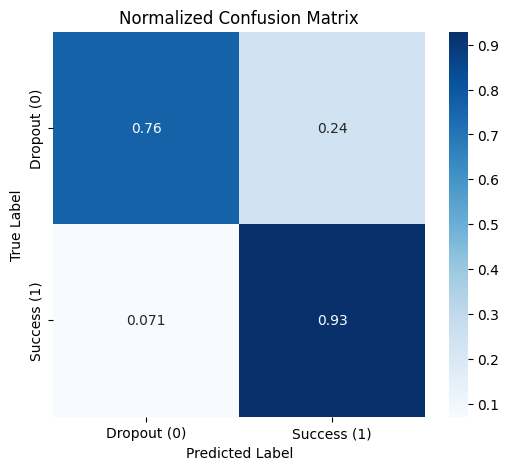

In [65]:
# Normalized confusion matrix
y_pred = clf.predict(X_test)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    cmap='Blues',
    xticklabels=['Dropout (0)', 'Success (1)'],
    yticklabels=['Dropout (0)', 'Success (1)']
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix')
plt.show()

In [66]:
# Retrain using only 1% of the training set
# 1% of the 90% train split = 0.9% of total dataset
X_train_1pct, _, y_train_1pct, _ = train_test_split(
    X_train, y_train, train_size=0.01, random_state=42, stratify=y_train
)

clf_1pct = RandomForestClassifier(random_state=42)
clf_1pct.fit(X_train_1pct, y_train_1pct)

test_acc_1pct = accuracy_score(y_test, clf_1pct.predict(X_test))
print(f'Testing Accuracy (trained on 1% data): {test_acc_1pct:.4f}')

Testing Accuracy (trained on 1% data): 0.8262
